# 实验四：频域图像滤波与傅里叶变换

**实验目的：**
掌握二维离散傅里叶变换（DFT）的物理意义，学会在频域中设计滤波器进行图像处理。

**实验准备：**
请确保当前目录下有一张名为 `lena.jpg` 的图像。


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def show_images(images, titles, figsize=(15, 5)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i+1)
        # 对于频域显示的浮点数，不严格限制 vmin/vmax
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 读取原始图像并转为灰度图
img = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("⚠️ 找不到 lena.jpg，请准备一张图片并重命名为 lena.jpg！")
else:
    print(f"图像读取成功！尺寸: {img.shape}")


图像读取成功！尺寸: (240, 320)


## 1. 二维快速傅里叶变换 (FFT)
我们将图像转换到频域，并将低频分量移动到图像中心，分别提取其**幅度谱**和**相位谱**。


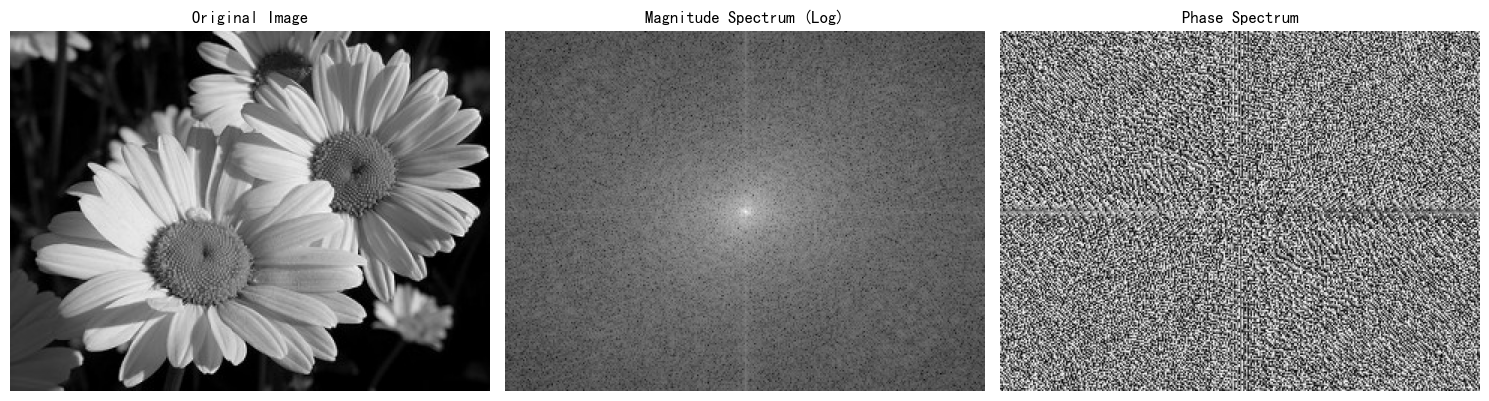

In [2]:
if img is not None:
    # 进行二维傅里叶变换，结果是一个复数数组
    f = np.fft.fft2(img)
    # 将低频分量从左上角移到图像中心
    fshift = np.fft.fftshift(f)

    # 计算幅度谱 (取绝对值)。因为范围极大，通常需要取对数以便观察
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

    # 计算相位谱 (取角度)
    phase_spectrum = np.angle(fshift)

    show_images([img, magnitude_spectrum, phase_spectrum], 
                ["Original Image", "Magnitude Spectrum (Log)", "Phase Spectrum"])


## 2. 幅度谱与相位谱的物理意义重建
我们将进行一个经典实验：只用幅度谱（丢弃相位），或只用相位谱（将幅度设为常数）进行逆傅里叶变换（IFFT）。
你会发现，**相位谱包含了图像绝大部分的结构和边缘信息**，而幅度谱仅包含亮度强弱分布。


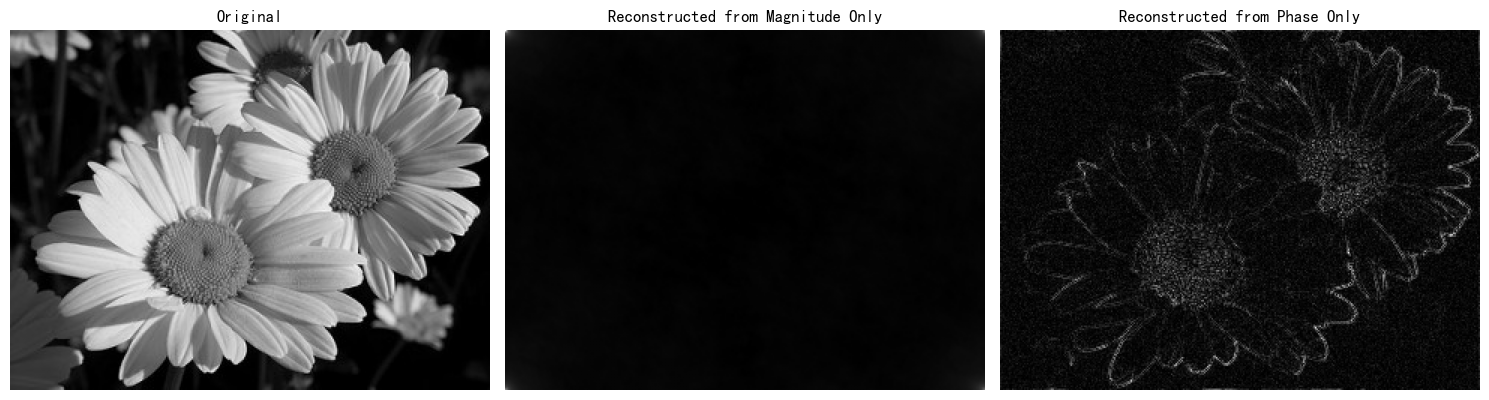

In [3]:
if img is not None:
    # --- 仅使用幅度重建 (相位设为0) ---
    # 构造复数: R * exp(i * 0)
    f_mag_only = np.abs(fshift) * np.exp(1j * 0)
    # 逆平移，然后逆变换
    img_mag_only = np.abs(np.fft.ifft2(np.fft.ifftshift(f_mag_only)))

    # --- 仅使用相位重建 (幅度设为1) ---
    # 构造复数: 1 * exp(i * phase)
    f_phase_only = 1 * np.exp(1j * phase_spectrum)
    img_phase_only = np.abs(np.fft.ifft2(np.fft.ifftshift(f_phase_only)))

    show_images([img, img_mag_only, img_phase_only], 
                ["Original", "Reconstructed from Magnitude Only", "Reconstructed from Phase Only"])


## 3. 频域低通滤波器 (平滑/去噪)
低通滤波的作用是保留中心低频，截断边缘高频。
* **理想低通滤波器 (ILPF)：** 截断非常生硬，会导致重建图像出现严重的水波纹（**振铃效应 Ringing Effect**）。
* **巴特沃斯低通滤波器 (BLPF)：** 过渡平滑，能有效缓解振铃效应。


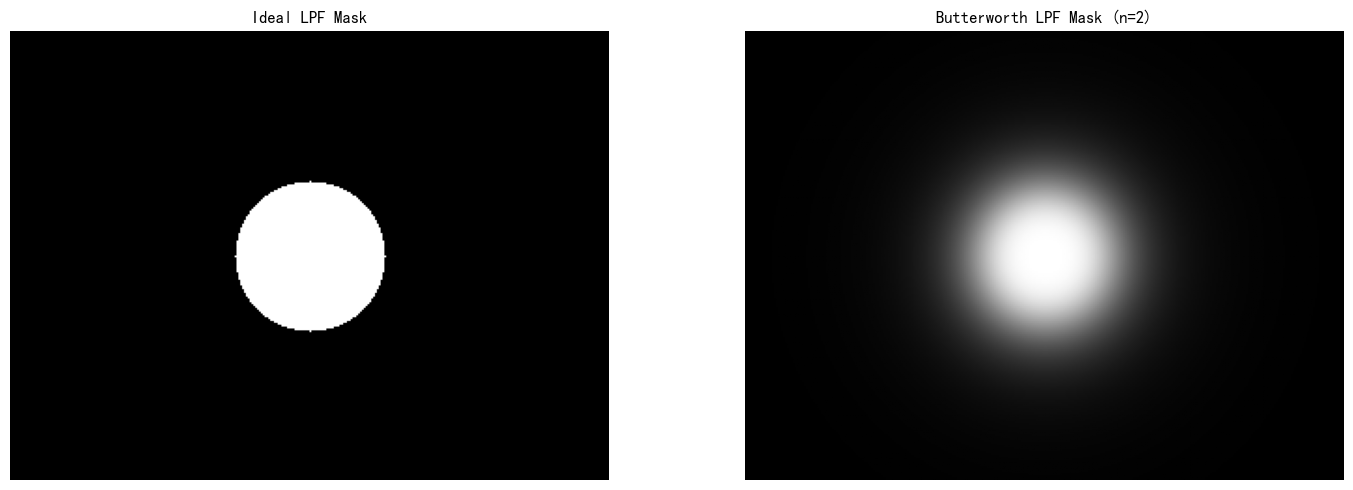

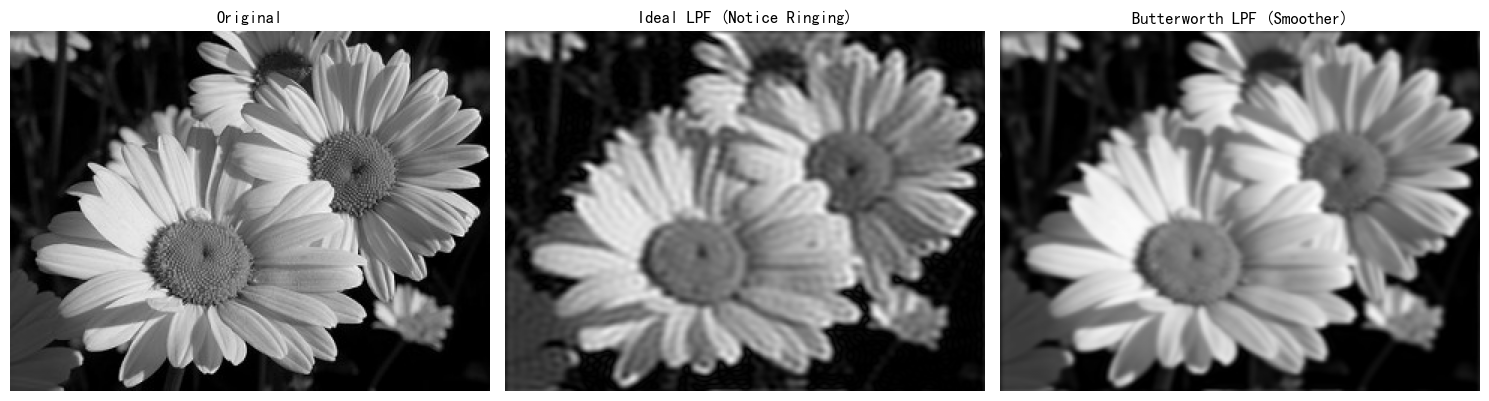

In [4]:
if img is not None:
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2  # 中心点坐标

    # 构造与图像同尺寸的距离矩阵 D(u, v)
    x = np.arange(cols) - ccol
    y = np.arange(rows) - crow
    X, Y = np.meshgrid(x, y)
    D = np.sqrt(X**2 + Y**2)

    # 截止频率 D0
    D0 = 40 

    # 1. 理想低通滤波器 (ILPF)
    H_ideal = np.zeros((rows, cols))
    H_ideal[D <= D0] = 1

    # 应用 ILPF 并逆变换
    fshift_ideal = fshift * H_ideal
    img_ideal = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_ideal)))

    # 2. 巴特沃斯低通滤波器 (BLPF) - 2阶
    n = 2
    H_butter = 1 / (1 + (D / D0)**(2 * n))

    # 应用 BLPF 并逆变换
    fshift_butter = fshift * H_butter
    img_butter = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_butter)))

    # 显示结果与滤波器形状
    show_images([H_ideal, H_butter], ["Ideal LPF Mask", "Butterworth LPF Mask (n=2)"])
    show_images([img, img_ideal, img_butter], 
                ["Original", "Ideal LPF (Notice Ringing)", "Butterworth LPF (Smoother)"])


## 4. 频域高通滤波器 (锐化/边缘提取)
高通滤波器与低通滤波器刚好相反：它屏蔽中心的低频能量，只让外围的高频通过。
这就等同于把图像的“平坦背景”去掉了，只留下“边缘的轮廓”。


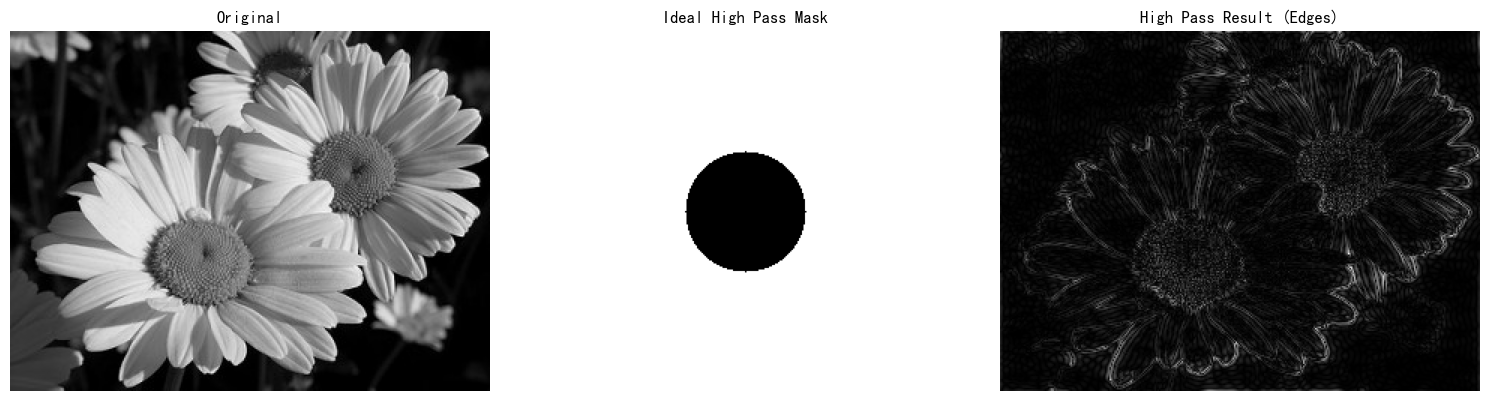

In [5]:
if img is not None:
    # 理想高通滤波器 (IHPF) = 1 - 理想低通滤波器
    H_high = 1 - H_ideal

    # 应用高通滤波器
    fshift_high = fshift * H_high

    # 逆变换并取绝对值
    img_high = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_high)))

    show_images([img, H_high, img_high], 
                ["Original", "Ideal High Pass Mask", "High Pass Result (Edges)"])
